In [24]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils import resample

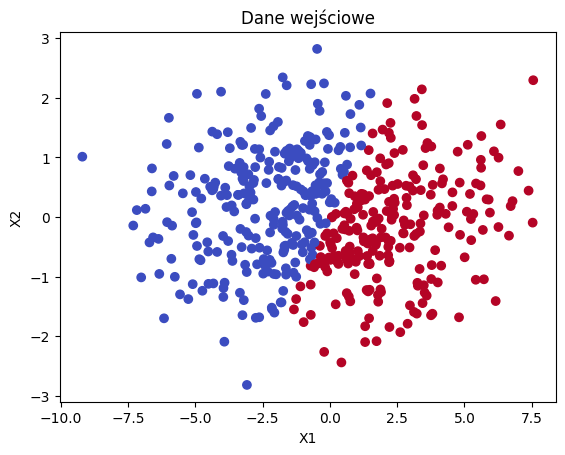

Liczność klas: [264 236]


In [25]:
# generowanie danych
X = np.random.randn(500, 2) * [3, 1]
y = (X[:, 0] > X[:, 1]).astype(int)

# wykres
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
plt.title("Dane wejściowe")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

# balans klas
print("Liczność klas:", np.bincount(y))

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
model = SVC(kernel='rbf')  # nieliniowy kernel

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy (bez balansowania):", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy (bez balansowania): 0.98
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        48
           1       0.98      0.98      0.98        52

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



In [28]:
# łączenie danych
train_data = np.hstack((X_train, y_train.reshape(-1, 1)))

# rozdzielenie klas
class_0 = train_data[train_data[:, -1] == 0]
class_1 = train_data[train_data[:, -1] == 1]

# oversampling mniejszej klasy
if len(class_0) > len(class_1):
    class_1_upsampled = resample(class_1, 
                                replace=True, 
                                n_samples=len(class_0), 
                                random_state=42)
    balanced_data = np.vstack((class_0, class_1_upsampled))
else:
    class_0_upsampled = resample(class_0, 
                                replace=True, 
                                n_samples=len(class_1), 
                                random_state=42)
    balanced_data = np.vstack((class_0_upsampled, class_1))

# ponowny podział
X_train_bal = balanced_data[:, :-1]
y_train_bal = balanced_data[:, -1]

print("Nowy balans klas:", np.bincount(y_train_bal.astype(int)))

Nowy balans klas: [216 216]


In [29]:
model_bal = SVC(kernel='rbf')

model_bal.fit(X_train_bal, y_train_bal)
y_pred_bal = model_bal.predict(X_test)

print("Accuracy (po balansowaniu):", accuracy_score(y_test, y_pred_bal))
print(classification_report(y_test, y_pred_bal))

Accuracy (po balansowaniu): 0.99
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        48
           1       1.00      0.98      0.99        52

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



In [30]:
model_weighted = SVC(kernel='rbf', class_weight='balanced')

model_weighted.fit(X_train, y_train)
y_pred_weighted = model_weighted.predict(X_test)

print("Accuracy (class_weight):", accuracy_score(y_test, y_pred_weighted))
print(classification_report(y_test, y_pred_weighted))

Accuracy (class_weight): 0.96
              precision    recall  f1-score   support

           0       0.98      0.94      0.96        48
           1       0.94      0.98      0.96        52

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100

